# Import

In [1]:
import os
import cv2
import glob
import shutil
import warnings
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [2]:
# warngin 무시
warnings.filterwarnings(action = 'ignore')

In [3]:
# Directory root
root = '/Users/toad/Documents/ToyProject/car_detection'

# Model-Train

In [6]:
# Load pretrained YOLO11n model
model = YOLO('yolo11n.pt')

# Transfer Learning with Custom Car Dataset
results = model.train(
    data=f'{root}/data.yaml',
    epochs = 5,
    imgsz=640,
    batch = 2, # cpu의 경우 Batch 사이즈가 작을 수록 학습 속도가 빠르다는 것을 토대로 설정해보았음
    device='cpu'
)

# Inference Test
results = model(f'{root}/dataset/images/train/syn_00004.png')

Ultralytics 8.3.171 🚀 Python-3.11.11 torch-2.2.2 CPU (Intel Core(TM) i5-8257U 1.40GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/toad/Documents/ToyProject/car_detection/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

train: Scanning /Users/toad/Documents/ToyProject/car_detection/dataset/labels/train.cache... 1197 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1197/1197 [00:00<?, ?it/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1227.3±98.6 MB/s, size: 2674.5 KB)



val: Scanning /Users/toad/Documents/ToyProject/car_detection/dataset/labels/val.cache... 399 images, 0 backgrounds, 0 corrupt: 100%|██████████| 399/399 [00:00<?, ?it/s]

Plotting labels to runs/detect/train10/labels.jpg... 


...

        5/5         0G     0.2308     0.2751     0.8071          3        640: 100%|██████████| 599/599 [12:20<00:00,  1.24s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [01:06<00:00,  1.50it/s]

                   all        399       1049          1          1      0.995      0.995



5 epochs completed in 1.102 hours.
Optimizer stripped from runs/detect/train10/weights/last.pt, 5.4MB
Optimizer stripped from runs/detect/train10/weights/best.pt, 5.4MB

Validating runs/detect/train10/weights/best.pt...
Ultralytics 8.3.171 🚀 Python-3.11.11 torch-2.2.2 CPU (Intel Core(TM) i5-8257U 1.40GHz)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 100/100 [01:01<00:00,  1.64it/s]


                   all        399       1049          1          1      0.995      0.995
Speed: 2.0ms preprocess, 80.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train10

image 1/1 /Users/toad/Documents/ToyProject/car_detection/dataset/images/train/syn_00004.png: 352x640 3 cars, 168.0ms
Speed: 4.4ms preprocess, 168.0ms inference, 1.5ms postprocess per image at shape (1, 3, 352, 640)


# Model-Test

In [4]:
model = YOLO(f'{root}/code/best_pt/best.pt')

In [9]:
results = model.val(
    data=f'{root}/data.yaml',
    split='test',
    batch=2,
    conf=0.7
)
print(results.summary())

Ultralytics 8.3.171 🚀 Python-3.11.11 torch-2.2.2 CPU (Intel Core(TM) i5-8257U 1.40GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1063.1±641.3 MB/s, size: 2489.3 KB)


val: Scanning /Users/toad/Documents/ToyProject/car_detection/dataset/labels/test.cache... 399 images, 0 backgrounds, 0 corrupt: 100%|██████████| 399/399 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 200/200 [01:08<00:00,  2.91it/s]


                   all        399       1045          1          1      0.995      0.995
Speed: 2.4ms preprocess, 89.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val2
[{'Class': 'car', 'Images': 399, 'Instances': 1045, 'Box-P': 1.0, 'Box-R': 1.0, 'Box-F1': 1.0, 'mAP50': 0.995, 'mAP50-95': 0.995}]


## Test Data 기반 성능 평가 결과

* Box-P : 1.0
* Box-R : 1.0
* Box-F1 : 1.0
* mAP50 : 0.995
* mAP50-95 : 0.995


# ONNX export

In [146]:
model.export(format='onnx', imgsz=640, simplify=True, nms=True)

Ultralytics 8.3.171 🚀 Python-3.11.11 torch-2.2.2 CPU (Intel Core(TM) i5-8257U 1.40GHz)

PyTorch: starting from '/Users/toad/Documents/ToyProject/car_detection/code/best_pt/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.2 MB)

ONNX: starting export with onnx 1.17.0 opset 17...
ONNX: slimming with onnxslim 0.1.64...
ONNX: export success ✅ 3.6s, saved as '/Users/toad/Documents/ToyProject/car_detection/code/best_pt/best.onnx' (10.1 MB)

Export complete (4.1s)
Results saved to /Users/toad/Documents/ToyProject/car_detection/code/best_pt
Predict:         yolo predict task=detect model=/Users/toad/Documents/ToyProject/car_detection/code/best_pt/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/Users/toad/Documents/ToyProject/car_detection/code/best_pt/best.onnx imgsz=640 data=/Users/toad/Documents/ToyProject/car_detection/data.yaml  
Visualize:       https://netron.app


'/Users/toad/Documents/ToyProject/car_detection/code/best_pt/best.onnx'

# Inference

### Inference .pt model


image 1/1 /Users/toad/Documents/ToyProject/car_detection/test.png: 416x640 2 cars, 156.5ms
Speed: 5.0ms preprocess, 156.5ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)


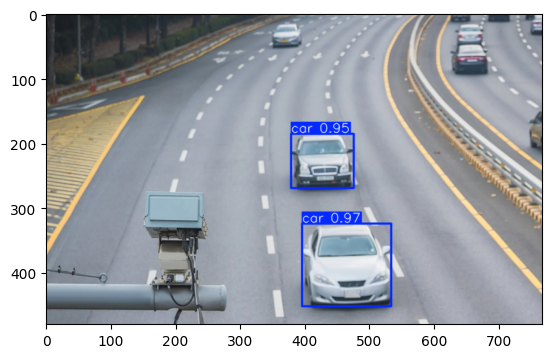

In [73]:
source = f'{root}/test.png'
results = model.predict(
    source,
    imgsz=640,
    conf=0.9
)
results[0].save(f'{root}/test_inference.png')

img = cv2.imread(f'{root}/test_inference.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

### Inference ONNX model

Loading /Users/toad/Documents/ToyProject/car_detection/code/best_pt/best.onnx for ONNX Runtime inference...
Using ONNX Runtime CPUExecutionProvider

image 1/1 /Users/toad/Documents/ToyProject/car_detection/test.png: 640x640 2 cars, 94.0ms
Speed: 6.6ms preprocess, 94.0ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)


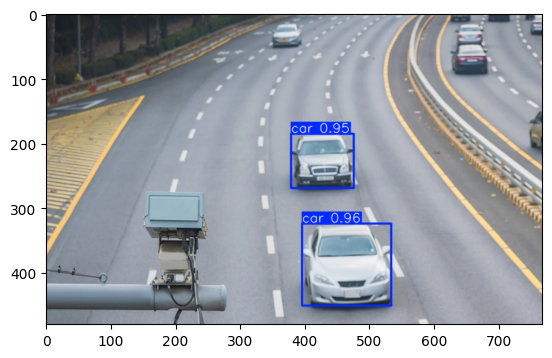

In [78]:
source = f'{root}/test.png'
onnx_model = YOLO(f'{root}/code/best_pt/best.onnx', task='detect')
results = onnx_model.predict(
    source,
    conf=0.9
)
results[0].save(f'{root}/test_inference.png')

img = cv2.imread(f'{root}/test_inference.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

*ONNX로 export한 모델의 추론 속도가 pytorch 파라미터로 내보낸 것 보다 약 40% 더 빨랐다.*

.pt = 156.1ms  
.onnx = 94.0ms

# onnxruntime Load model and Inference

In [177]:
import onnxruntime as ort
import numpy as np
import time

### 전처리 후처리 함수

전처리

In [148]:
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    img_w, img_h = image.shape[1], image.shape[0]

    img = cv2.resize(image, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.transpose(2, 0, 1)
    img = img.reshape(1, 3, 640, 640)

    img = img / 255.0
    img = img.astype(np.float32)
    return img

후처리 및 이미지 출력

In [174]:
def postprocess_image(image_path, predictions):
    # 차원 축소
    predictions = np.array(predictions).squeeze()  # (300, 6)

    # 원본 이미지 복사
    origin_image = cv2.imread(source)
    draw_img = origin_image.copy()

    # 클래스 이름 (필요시 수정)
    class_names = ["car"]
    scale_x = img_w / 640
    scale_y = img_h / 640
    for det in predictions:
        x1, y1, x2, y2, score, cls_id = det
        if score < 0.9:  # Confidence threshold
            continue
        # 스케일 변환
        x1 = int(x1 * scale_x)
        y1 = int(y1 * scale_y)
        x2 = int(x2 * scale_x)
        y2 = int(y2 * scale_y)

        # 정수 좌표로 변환
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cls_id = int(cls_id)

        # 박스 그리기
        cv2.rectangle(draw_img, (x1, y1), (x2, y2), (255, 0, 0), 2) # BGR기준

        # 클래스 & 점수 표시
        label = f"{class_names[cls_id]} {score:.2f}"
        cv2.putText(draw_img, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # 이미지 저장
    cv2.imwrite(f'{root}/onnx_inference.png', draw_img, params=None)

    # BGR → RGB 변환
    draw_img = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)
    return draw_img

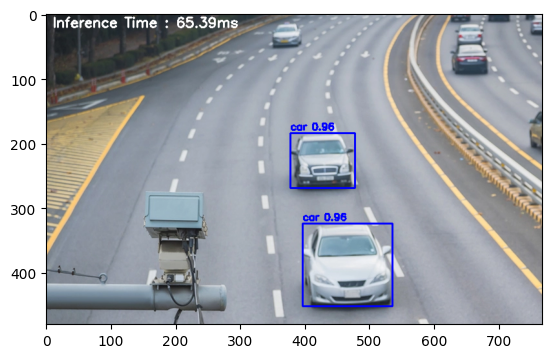

In [193]:
model_path = f'{root}/code/best_pt/best.onnx'
onnx_model = ort.InferenceSession(model_path)
image = preprocess_image(source)

start = time.time()
predictions = onnx_model.run(None, {"images": image})
end = time.time()

result_image = postprocess_image(source, predictions)

# 추론 시간
infer_time = end - start  # 초 단위
infer_ms = infer_time * 1000  # 밀리초 단위
text = f'Inference Time : {infer_ms:0.4}ms'
cv2.putText(result_image, text, (10,20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
plt.imshow(result_image)

onnxruntime을 통해 65.39ms까지 단축된 추론 시간